# WiC — Notebook finale completo (ablation multi-backbone + submission)

**Candidato:** Claudio Daloiso · **Relatore:** Prof.ssa Fallucchi · **Correlatore:** Dott. Gozzi

Pipeline unica e *resumable*. Tutto viene salvato su Google Drive in `MyDrive/wic_paper/`:
- `ablation_results.json` — metriche + dev_preds di ogni run (per resumability e McNemar)
- `final_model/` — il modello finale addestrato (così l'addestramento resta salvato)
- `submission/` — `WiC.jsonl` (SuperGLUE) **e** `output.txt` (WiC standalone), già zippati
- `ablation_plot.png` — grafico riassuntivo

Se la sessione cade, **rilancia tutte le celle**: i run già fatti vengono saltati e il modello finale viene ricaricato da Drive.

In [ ]:
!pip install -q transformers datasets evaluate accelerate sentencepiece
!pip install -q scikit-learn pandas numpy matplotlib scipy
print("Pacchetti installati")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.0 MB/s eta 0:00:00
Pacchetti installati


## 1. Setup, device e persistenza su Drive
Qui si monta Drive e si definiscono i percorsi dove viene salvato **tutto**.

In [ ]:
!pip -q install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.9 MB/s eta 0:00:00


In [ ]:
!pip -q install evaluate datasets transformers accelerate scikit-learn scipy

In [ ]:
import os, json, zipfile, warnings, gc, shutil, time, urllib.request
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch, torch.nn as nn
from datasets import Dataset as HFDataset
from transformers import (AutoTokenizer, AutoConfig, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding, set_seed)
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import binomtest
import evaluate
warnings.filterwarnings("ignore")

# patch difensiva per import torchvision su alcune immagini Colab
try:
    import torchvision.io as _tvio
    if not hasattr(_tvio, "VideoReader"):
        class _Stub: pass
        _tvio.VideoReader = _Stub
except Exception:
    pass

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "| Torch:", torch.__version__)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# --- Persistenza su Google Drive: TUTTO viene salvato qui ---
from google.colab import drive
drive.mount("/content/drive")
PERSIST_DIR  = Path("/content/drive/MyDrive/wic_paper")
RESULTS_PATH = PERSIST_DIR / "ablation_results.json"
MODELS_BASE  = PERSIST_DIR / "models"            # un modello per ogni config (niente collisioni)
POINTER_PATH = PERSIST_DIR / "final_pointer.json"  # quale config e' il modello finale
SUBMIT_DIR   = PERSIST_DIR / "submission"
PLOT_PATH    = PERSIST_DIR / "ablation_plot.png"
for d in (PERSIST_DIR, MODELS_BASE, SUBMIT_DIR):
    d.mkdir(parents=True, exist_ok=True)
Path("./outputs").mkdir(exist_ok=True)

def final_model_dir(backbone, condition, seed):
    """Cartella SPECIFICA per (backbone, condizione, seed): evita di riusare per errore un vecchio modello."""
    safe = backbone.replace("/", "__")
    return MODELS_BASE / f"final__{safe}__{condition}__seed{seed}"

print("Tutto verra salvato in:", PERSIST_DIR)

Device: cuda | Torch: 2.11.0+cu128
GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tutto verra salvato in: /content/drive/MyDrive/wic_paper


## 2. Caricamento dataset WiC (SuperGLUE)
Train 5.428 · Dev 638 · Test 1.400 (etichette del test nascoste).

In [ ]:
DATA_DIR = Path("./wic_data"); DATA_DIR.mkdir(exist_ok=True)
zip_path = DATA_DIR / "WiC.zip"
WIC_URL = "https://dl.fbaipublicfiles.com/glue/superglue/data/v2/WiC.zip"
if not zip_path.exists():
    print("Download dataset..."); urllib.request.urlretrieve(WIC_URL, zip_path)
with zipfile.ZipFile(zip_path) as z:
    z.extractall(DATA_DIR)

def load_wic_jsonl(fp):
    rows = []
    with open(fp, encoding="utf-8") as f:
        for line in f:
            d = json.loads(line)
            rows.append({
                "idx": d.get("idx", -1), "word": d["word"], "pos": d.get("pos", "N"),
                "sentence1": d["sentence1"], "sentence2": d["sentence2"],
                "start1": d["start1"], "end1": d["end1"],
                "start2": d["start2"], "end2": d["end2"],
                "label": int(d["label"]) if d.get("label") is not None else None,
            })
    return pd.DataFrame(rows)

base = DATA_DIR / "WiC"
train_df = load_wic_jsonl(base / "train.jsonl")
dev_df   = load_wic_jsonl(base / "val.jsonl")
test_df  = load_wic_jsonl(base / "test.jsonl")
print(f"Train {len(train_df)} | Dev {len(dev_df)} | Test {len(test_df)}")
if len(test_df) != 1400:
    print(f"ATTENZIONE: il test set ha {len(test_df)} esempi invece dei 1400 attesi per WiC.")

## 3. Preprocessing parametrico (span highlighting + prefisso POS)
`add_features` genera tutte e quattro le varianti dell'ablation 2x2.

In [ ]:
HIGHLIGHT_TOKENS = ["<TW>", "</TW>"]
POS_MAP = {"N": "noun", "V": "verb", "J": "adjective", "R": "adverb"}

def highlight_word(sentence, start, end):
    try:
        s, e = int(start), int(end)
        if not (0 <= s < e <= len(sentence)):
            return sentence
        return sentence[:s] + "<TW>" + sentence[s:e] + "</TW>" + sentence[e:]
    except Exception:
        return sentence

def add_features(df, use_highlight, use_prefix):
    df = df.copy()
    def make_sent(row, n):
        s = row[f"sentence{n}"]
        if use_highlight:
            s = highlight_word(s, row[f"start{n}"], row[f"end{n}"])
        if use_prefix:
            s = f"{row['word']} ({POS_MAP.get(row['pos'], 'word')}): " + s
        return s
    df["s1_final"] = df.apply(lambda r: make_sent(r, 1), axis=1)
    df["s2_final"] = df.apply(lambda r: make_sent(r, 2), axis=1)
    return df

print("Anteprima 4 condizioni (stesso esempio):")
for hl, px in [(True, True), (False, True), (True, False), (False, False)]:
    r = add_features(train_df.iloc[[0]], hl, px).iloc[0]
    print(f"  hl={hl}, px={px} -> {r['s1_final']}")

Anteprima 4 condizioni (stesso esempio):
  hl=True, px=True -> place (noun): Do you want to come over to my <TW>place</TW> later?
  hl=False, px=True -> place (noun): Do you want to come over to my place later?
  hl=True, px=False -> Do you want to come over to my <TW>place</TW> later?
  hl=False, px=False -> Do you want to come over to my place later?


## 3-bis. Audit degli indici di span
Controllo difensivo: verifica quanti span avrebbero indici fuori range. Serve per documentare che l'highlighting non introduce fallback silenziosi.

In [ ]:
def audit_indices(df, name):
    bad = 0
    for _, r in df.iterrows():
        for n in (1, 2):
            try:
                s, e = int(r[f"start{n}"]), int(r[f"end{n}"])
                sent = r[f"sentence{n}"]
                if not (0 <= s < e <= len(sent)):
                    bad += 1
            except Exception:
                bad += 1
    total = len(df) * 2
    print(f"{name}: {bad} span fuori range su {total} ({bad/total*100:.3f}%)")
    return bad, total

print("Audit indici target:")
audit_train = audit_indices(train_df, "Train")
audit_dev   = audit_indices(dev_df,   "Dev")
audit_test  = audit_indices(test_df,  "Test")


Audit indici target:
Train: 0 span fuori range su 10856 (0.000%)
Dev: 0 span fuori range su 1276 (0.000%)
Test: 0 span fuori range su 2800 (0.000%)


## 4. Configurazione
**Per il paper** lascia >1 backbone. **Per chiudere solo il minimo** (singolo modello + submission) metti `BACKBONES = ["microsoft/deberta-large"]`.

In [ ]:
# Backbone dell'ablation multi-modello (il cuore del paper).
# Aggiungere/togliere modelli qui: tutto il resto si adatta da solo.
BACKBONES = [
    "microsoft/deberta-large",       # gia validato
    "roberta-large",                 # secondo backbone (sicuro)
    # "microsoft/deberta-v3-large",  # opzionale: richiede FP32 (gia impostato)
]

MAX_LEN   = 128
USE_FP16  = False     # FP32 per stabilita (obbligatorio per DeBERTa-v3)
EPOCHS    = 4         # niente early stopping: durata controllata
SEEDS     = [42, 123, 2024]
SENSEBERT = 0.721     # NB: SenseBERT e sul TEST set, NON confrontabile col dev

# Iperparametri Optuna (tunati su DeBERTa-large). Trasferiti agli altri backbone:
# validi per il DELTA highlight/prefisso ENTRO ciascun modello (il claim del paper),
# non per confronti assoluti tra modelli diversi -> da dichiarare in metodologia.
BEST_PARAMS = {
    "learning_rate": 8.655684637181687e-06,
    "weight_decay": 0.0384178539730063,
    "hidden_dropout": 0.09350951469683673,
    "attention_dropout": 0.06661222055295538,
    "warmup_ratio": 0.07598012902842396,
    "label_smoothing": 0.020917269578948443,
}

# 2x2 fattoriale, core-first (full e no_highlight per primi: delta che risponde alla domanda)
CONDITIONS = [
    {"name": "full",         "use_highlight": True,  "use_prefix": True},
    {"name": "no_highlight", "use_highlight": False, "use_prefix": True},
    {"name": "no_prefix",    "use_highlight": True,  "use_prefix": False},
    {"name": "plain",        "use_highlight": False, "use_prefix": False},
]

# Modello finale -> verra addestrato, SALVATO su Drive e usato per la submission.
# Lascia None per auto-selezione del miglior (backbone, condizione) dall'ablation.
# None => il modello finale viene scelto DOPO l'ablation (combinazione migliore
# tra quelle complete su tutti i seed). Piu' difendibile in un paper.
FINAL_BACKBONE  = "microsoft/deberta-large"
FINAL_CONDITION = "no_highlight"
FINAL_SEED      = 42

n_runs = len(BACKBONES) * len(CONDITIONS) * len(SEEDS)
print(f"Backbone {len(BACKBONES)} | Condizioni {len(CONDITIONS)} | Seed {len(SEEDS)} | Run totali: {n_runs}")

Backbone 2 | Condizioni 4 | Seed 3 | Run totali: 24


## 4-bis. (Opzionale) Importa i run gia fatti in precedenza
Se avevi gia girato l'ablation su DeBERTa-large in `MyDrive/wic_ablation/`, questa cella li riusa così non li riaddestri.

In [ ]:
def load_results():
    if RESULTS_PATH.exists():
        with open(RESULTS_PATH) as f:
            return json.load(f)
    return []

def save_results(res):
    with open(RESULTS_PATH, "w") as f:
        json.dump(res, f, indent=2)

OLD_RESULTS = Path("/content/drive/MyDrive/wic_ablation/ablation_results.json")
res = load_results()

# Import robusto: importa sempre i run mancanti, anche se in wic_paper esiste gia qualche run DeBERTa parziale.
if OLD_RESULTS.exists():
    old = json.load(open(OLD_RESULTS))
    seen = {(r.get("backbone", "microsoft/deberta-large"), r["condition"], r["seed"]) for r in res}
    added = 0
    for r in old:
        r.setdefault("backbone", "microsoft/deberta-large")
        k = (r["backbone"], r["condition"], r["seed"])
        if k not in seen:
            res.append(r)
            seen.add(k)
            added += 1
    save_results(res)
    print(f"Importati {added} run mancanti da {OLD_RESULTS}")
else:
    print("File precedente non trovato: nessuna migrazione eseguita.")


Importati 0 run mancanti da /content/drive/MyDrive/wic_ablation/ablation_results.json


## 5. Helper: trainer pesato, training args, modello, dati per-condizione

In [ ]:
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, label_smoothing=0.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.label_smoothing = label_smoothing
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        w = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss = nn.CrossEntropyLoss(weight=w, label_smoothing=self.label_smoothing)(
            logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def build_training_args(out_dir, seed):
    return TrainingArguments(
        output_dir=str(out_dir), num_train_epochs=EPOCHS,
        per_device_train_batch_size=4, per_device_eval_batch_size=8,
        gradient_accumulation_steps=4,
        learning_rate=BEST_PARAMS["learning_rate"],
        weight_decay=BEST_PARAMS["weight_decay"],
        warmup_ratio=BEST_PARAMS["warmup_ratio"], lr_scheduler_type="cosine",
        eval_strategy="epoch", save_strategy="epoch",
        load_best_model_at_end=True, metric_for_best_model="accuracy", greater_is_better=True,
        fp16=USE_FP16, gradient_checkpointing=False,
        logging_steps=100, report_to="none", save_total_limit=1, seed=seed,
        dataloader_num_workers=2, disable_tqdm=False,
    )

def make_model(model_name, tokenizer):
    cfg = AutoConfig.from_pretrained(model_name, num_labels=2)
    cfg.hidden_dropout_prob = BEST_PARAMS["hidden_dropout"]
    cfg.attention_probs_dropout_prob = BEST_PARAMS["attention_dropout"]
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, config=cfg, ignore_mismatched_sizes=True)
    model.resize_token_embeddings(len(tokenizer))  # no-op se non sono stati aggiunti token
    return model

def build_condition_data(model_name, cond):
    tok = AutoTokenizer.from_pretrained(model_name)
    if cond["use_highlight"]:
        tok.add_special_tokens({"additional_special_tokens": HIGHLIGHT_TOKENS})
    tr = add_features(train_df, cond["use_highlight"], cond["use_prefix"])
    dv = add_features(dev_df,   cond["use_highlight"], cond["use_prefix"])
    def tok_fn(ex):
        out = tok(ex["s1_final"], ex["s2_final"], max_length=MAX_LEN, truncation=True, padding=False)
        out["labels"] = ex["label"]; return out
    train_d = HFDataset.from_pandas(tr[["s1_final","s2_final","label"]].reset_index(drop=True)) \
        .map(tok_fn, remove_columns=["s1_final","s2_final","label"])
    dev_d = HFDataset.from_pandas(dv[["s1_final","s2_final","label"]].reset_index(drop=True)) \
        .map(tok_fn, remove_columns=["s1_final","s2_final","label"])
    return tok, train_d, dev_d

cw = compute_class_weight("balanced", classes=np.array([0,1]), y=train_df["label"].values)
CLASS_WEIGHTS = torch.tensor(cw, dtype=torch.float)
acc_metric = evaluate.load("accuracy"); f1_metric = evaluate.load("f1")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": acc_metric.compute(predictions=preds, references=labels)["accuracy"],
            "f1": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]}
print("Helper pronti. Class weights:", cw.round(4))

Helper pronti. Class weights: [1. 1.]


## 6. Loop di ablation multi-backbone (resumable, niente early stopping)
Salva i risultati su Drive **dopo ogni run**. I checkpoint pesanti NON vengono tenuti (riempirebbero Drive): per l'ablation bastano metriche + dev_preds. Il modello finale, quello sì, viene salvato (sez. 10).

In [ ]:
results = load_results()
done = {(r["backbone"], r["condition"], r["seed"]) for r in results}
print(f"Run gia completati: {len(done)}/{len(BACKBONES)*len(CONDITIONS)*len(SEEDS)}")

for backbone in BACKBONES:
    for cond in CONDITIONS:
        cname = cond["name"]
        if all((backbone, cname, s) in done for s in SEEDS):
            print(f"[SKIP] {backbone} / {cname} gia completo"); continue
        print("\n" + "#"*70)
        print(f"# {backbone} | {cname} (hl={cond['use_highlight']}, px={cond['use_prefix']})")
        print("#"*70)
        tok, train_d, dev_d = build_condition_data(backbone, cond)
        for seed in SEEDS:
            if (backbone, cname, seed) in done:
                print(f"  [skip] seed {seed}"); continue
            print(f"\n=== {backbone} | {cname} | seed {seed} ===")
            set_seed(seed); gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
            out_dir = Path(f"./outputs/{backbone.split('/')[-1]}_{cname}_seed{seed}")
            if out_dir.exists(): shutil.rmtree(out_dir)
            out_dir.mkdir(parents=True)
            model = make_model(backbone, tok)
            trainer = WeightedTrainer(
                model=model, args=build_training_args(out_dir, seed),
                train_dataset=train_d, eval_dataset=dev_d,
                data_collator=DataCollatorWithPadding(tok), compute_metrics=compute_metrics,
                class_weights=CLASS_WEIGHTS, label_smoothing=BEST_PARAMS["label_smoothing"])
            t0 = time.time(); trainer.train(); mins = (time.time()-t0)/60
            em = trainer.evaluate()
            dev_preds = np.argmax(trainer.predict(dev_d).predictions, axis=-1).tolist()
            results.append({
                "backbone": backbone, "condition": cname,
                "use_highlight": cond["use_highlight"], "use_prefix": cond["use_prefix"],
                "seed": seed, "accuracy": float(em["eval_accuracy"]), "f1": float(em["eval_f1"]),
                "loss": float(em["eval_loss"]), "train_minutes": float(mins), "dev_preds": dev_preds,
            })
            save_results(results)   # <-- salvato su Drive dopo OGNI run
            done.add((backbone, cname, seed))
            print(f"  >>> dev acc={em['eval_accuracy']*100:.2f}% F1={em['eval_f1']*100:.2f}% "
                  f"{mins:.1f} min  [salvato su Drive]")
            del model, trainer; gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
            shutil.rmtree(out_dir, ignore_errors=True)
print("\nABLATION COMPLETATA (o ripresa: rilancia se mancano run)")

Run gia completati: 24/24
[SKIP] microsoft/deberta-large / full gia completo
[SKIP] microsoft/deberta-large / no_highlight gia completo
[SKIP] microsoft/deberta-large / no_prefix gia completo
[SKIP] microsoft/deberta-large / plain gia completo
[SKIP] roberta-large / full gia completo
[SKIP] roberta-large / no_highlight gia completo
[SKIP] roberta-large / no_prefix gia completo
[SKIP] roberta-large / plain gia completo

ABLATION COMPLETATA (o ripresa: rilancia se mancano run)


## 7. Aggregazione: media +/- std per (backbone, condizione) e delta vs full

In [ ]:
results = load_results()
backbones_seen = [b for b in BACKBONES if any(r["backbone"] == b for r in results)]

summary_rows = []
for backbone in backbones_seen:
    print("="*78)
    print(f"Backbone: {backbone}")
    print(f"{'Condizione':<14}{'n':<4}{'Acc media':<18}{'F1 media':<18}{'d vs full':<12}")
    print("-"*70)

    agg = {}
    for cond in CONDITIONS:
        rs = [r for r in results if r["backbone"] == backbone and r["condition"] == cond["name"]]
        if not rs:
            continue
        accs = np.array([r["accuracy"] for r in rs])
        f1s  = np.array([r["f1"] for r in rs])
        agg[cond["name"]] = {
            "n": len(rs),
            "acc_mean": float(accs.mean()),
            "acc_std": float(accs.std(ddof=1) if len(accs) > 1 else 0.0),
            "f1_mean": float(f1s.mean()),
            "f1_std": float(f1s.std(ddof=1) if len(f1s) > 1 else 0.0),
        }

    full_mean = agg["full"]["acc_mean"] if "full" in agg else None

    for cond in CONDITIONS:
        cn = cond["name"]
        if cn not in agg:
            continue
        a = agg[cn]
        delta = None if full_mean is None else (a["acc_mean"] - full_mean) * 100
        print(f"{cn:<14}{a['n']:<4}{a['acc_mean']*100:>6.2f} +/- {a['acc_std']*100:4.2f}%    "
              f"{a['f1_mean']*100:>6.2f} +/- {a['f1_std']*100:4.2f}%    "
              f"{'' if delta is None else f'{delta:+.2f} pp':<12}")

        summary_rows.append({
            "backbone": backbone,
            "condition": cn,
            "n": a["n"],
            "acc_mean": a["acc_mean"],
            "acc_std": a["acc_std"],
            "f1_mean": a["f1_mean"],
            "f1_std": a["f1_std"],
            "delta_vs_full_pp": delta,
        })

    if "full" in agg and "no_highlight" in agg:
        d = (agg["full"]["acc_mean"] - agg["no_highlight"]["acc_mean"]) * 100
        print(f"  >>> Impatto highlighting (full - no_highlight): {d:+.2f} pp")

summary_df = pd.DataFrame(summary_rows)
summary_csv = PERSIST_DIR / "ablation_summary.csv"
summary_df.to_csv(summary_csv, index=False)


Backbone: microsoft/deberta-large
Condizione    n   Acc media         F1 media          d vs full   
----------------------------------------------------------------------
full          3    73.46 +/- 1.46%     73.35 +/- 1.55%    +0.00 pp    
no_highlight  3    73.72 +/- 0.55%     73.49 +/- 0.48%    +0.26 pp    
no_prefix     3    71.84 +/- 0.74%     71.71 +/- 0.67%    -1.62 pp    
plain         3    70.69 +/- 1.13%     70.19 +/- 1.26%    -2.77 pp    
  >>> Impatto highlighting (full - no_highlight): -0.26 pp
Backbone: roberta-large
Condizione    n   Acc media         F1 media          d vs full   
----------------------------------------------------------------------
full          3    72.10 +/- 0.87%     71.87 +/- 0.96%    +0.00 pp    
no_highlight  3    72.52 +/- 0.36%     72.37 +/- 0.38%    +0.42 pp    
no_prefix     3    71.53 +/- 1.92%     71.41 +/- 1.97%    -0.57 pp    
plain         3    71.21 +/- 1.10%     70.92 +/- 1.26%    -0.89 pp    
  >>> Impatto highlighting (full - no_h

## 8. Significativita: McNemar per seed + Holm (niente pooling tra seed)
Ogni test McNemar resta sui 638 esempi distinti del singolo seed (indipendenza ok). Holm corregge i 4 contrasti del 2x2 entro ciascun seed; i seed sono repliche -> si riporta **k/3 significativi dopo Holm**. Contrasto primario: `full vs no_highlight`.

In [ ]:
def mcnemar_exact(pa, pb, gold):
    a, b, g = np.array(pa), np.array(pb), np.array(gold)
    n01 = int(np.sum((a == g) & ~(b == g)))   # A corretto, B sbagliato
    n10 = int(np.sum(~(a == g) & (b == g)))   # A sbagliato, B corretto
    n = n01 + n10
    p = 1.0 if n == 0 else binomtest(min(n01, n10), n, 0.5, alternative="two-sided").pvalue
    return n01, n10, p

def holm_adjust(pvals):
    """Holm-Bonferroni: p-value aggiustati, nell'ordine originale."""
    m = len(pvals)
    order = sorted(range(m), key=lambda i: pvals[i])
    adj = [0.0] * m
    running = 0.0
    for rank, i in enumerate(order):
        running = max(running, (m - rank) * pvals[i])
        adj[i] = min(1.0, running)
    return adj

gold = dev_df["label"].values
by = {}
for r in results:
    by.setdefault((r["backbone"], r["condition"]), {})[r["seed"]] = r["dev_preds"]

# Contrasti fattoriali:
# - Highlight effect con prefisso: full vs no_highlight
# - Highlight effect senza prefisso: no_prefix vs plain
# - Prefix effect con highlighting: full vs no_prefix
# - Prefix effect senza highlighting: no_highlight vs plain
CONTRASTS = [
    ("highlight_effect_with_prefix", "full", "no_highlight"),
    ("highlight_effect_without_prefix", "no_prefix", "plain"),
    ("prefix_effect_with_highlight", "full", "no_prefix"),
    ("prefix_effect_without_highlight", "no_highlight", "plain"),
]

mcnemar_rows = []
print("McNemar pareato sui contrasti principali")
print("-"*90)

for backbone in backbones_seen:
    print(f"\nBackbone: {backbone}")
    for contrast_name, a_cond, b_cond in CONTRASTS:
        ka, kb = (backbone, a_cond), (backbone, b_cond)
        if ka not in by or kb not in by:
            continue
        print(f"  {contrast_name}: {a_cond} vs {b_cond}")
        pv = []
        for seed in SEEDS:
            if seed in by[ka] and seed in by[kb]:
                n01, n10, p = mcnemar_exact(by[ka][seed], by[kb][seed], gold)
                pv.append(p)
                sig = "SIGNIFICATIVO" if p < 0.05 else "non significativo"
                print(f"    seed {seed}: {a_cond}-only={n01:3d} | {b_cond}-only={n10:3d} | p={p:.4f} ({sig})")
                mcnemar_rows.append({
                    "backbone": backbone,
                    "contrast": contrast_name,
                    "condition_A": a_cond,
                    "condition_B": b_cond,
                    "seed": seed,
                    "A_only_correct": n01,
                    "B_only_correct": n10,
                    "p_value": p,
                    "significant_005": p < 0.05,
                })
        if pv:
            print(f"    -> {sum(p < 0.05 for p in pv)}/{len(pv)} seed significativi")

# === Confronti multipli: Holm applicato ENTRO ogni (backbone, seed) ===
# NIENTE pooling tra seed: ogni McNemar resta sui 638 esempi DISTINTI di quel seed
# (indipendenza rispettata). I seed sono repliche -> riportiamo "k/3 dopo Holm".
# Nota: Holm controlla la FWER anche sotto dipendenza dei test, quindi e' la
# correzione adatta; la famiglia e' i 4 contrasti del 2x2.
from collections import defaultdict
groups = defaultdict(list)
for r in mcnemar_rows:
    groups[(r["backbone"], r["seed"])].append(r)
for (_bk, _sd), rows in groups.items():
    for r, pa in zip(rows, holm_adjust([rr["p_value"] for rr in rows])):
        r["p_holm"] = pa
        r["significant_holm_005"] = bool(pa < 0.05)

mcnemar_df = pd.DataFrame(mcnemar_rows)
mcnemar_csv = PERSIST_DIR / "mcnemar_contrasts.csv"
mcnemar_df.to_csv(mcnemar_csv, index=False)

print("\n" + "="*92)
print("Sintesi dopo Holm (famiglia = 4 contrasti, entro ciascun seed)")
print("="*92)
for backbone in backbones_seen:
    print(f"\nBackbone: {backbone}")
    for contrast_name, a_cond, b_cond in CONTRASTS:
        sub = [r for r in mcnemar_rows if r["backbone"]==backbone and r["contrast"]==contrast_name]
        if not sub:
            continue
        k = sum(r["significant_holm_005"] for r in sub)
        praw = [round(r["p_value"], 4) for r in sub]
        print(f"  {contrast_name:<34} {k}/{len(sub)} seed signif. dopo Holm | p grezzi={praw}")
print("\nCSV salvato:", mcnemar_csv, "(con colonne p_holm, significant_holm_005)")


McNemar pareato sui contrasti principali
------------------------------------------------------------------------------------------

Backbone: microsoft/deberta-large
  highlight_effect_with_prefix: full vs no_highlight
    seed 42: full-only= 45 | no_highlight-only= 37 | p=0.4397 (non significativo)
    seed 123: full-only= 46 | no_highlight-only= 43 | p=0.8323 (non significativo)
    seed 2024: full-only= 44 | no_highlight-only= 60 | p=0.1410 (non significativo)
    -> 0/3 seed significativi
  highlight_effect_without_prefix: no_prefix vs plain
    seed 42: no_prefix-only= 60 | plain-only= 45 | p=0.1716 (non significativo)
    seed 123: no_prefix-only= 59 | plain-only= 46 | p=0.2414 (non significativo)
    seed 2024: no_prefix-only= 43 | plain-only= 49 | p=0.6024 (non significativo)
    -> 0/3 seed significativi
  prefix_effect_with_highlight: full vs no_prefix
    seed 42: full-only= 46 | no_prefix-only= 31 | p=0.1100 (non significativo)
    seed 123: full-only= 47 | no_prefix-only=

## 9. Grafico riassuntivo (salvato su Drive)

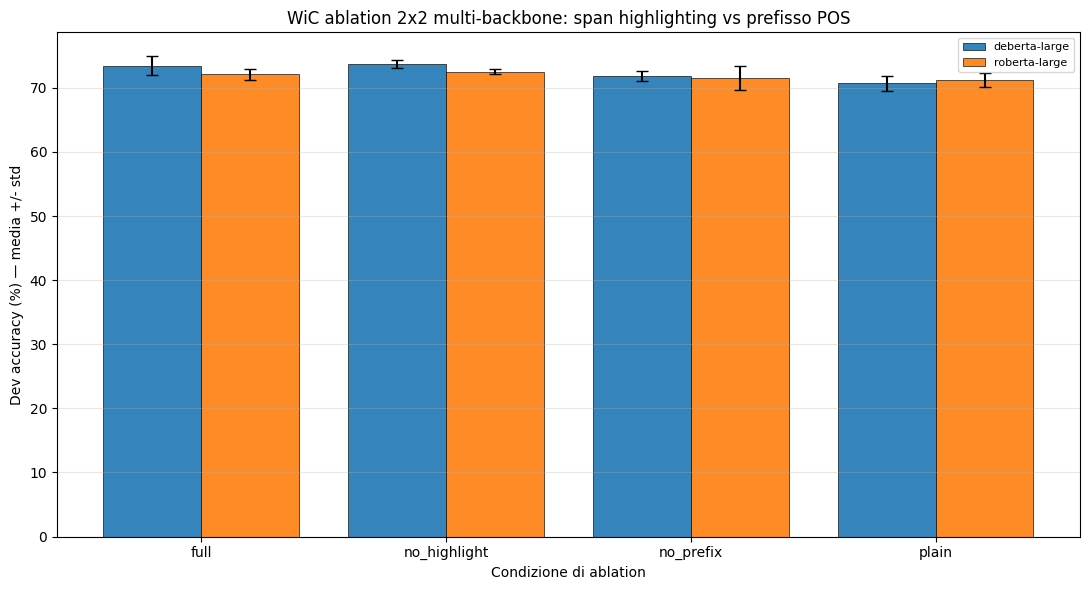

Grafico salvato su Drive: /content/drive/MyDrive/wic_paper/ablation_plot.png


In [ ]:
cond_names = [c["name"] for c in CONDITIONS]
x = np.arange(len(cond_names))
width = 0.8 / max(len(backbones_seen), 1)

fig, ax = plt.subplots(figsize=(11, 6))

for i, backbone in enumerate(backbones_seen):
    means, stds = [], []
    for cn in cond_names:
        rs = [r for r in results if r["backbone"] == backbone and r["condition"] == cn]
        accs = np.array([r["accuracy"] for r in rs]) * 100 if rs else np.array([np.nan])
        means.append(np.nanmean(accs))
        stds.append(accs.std(ddof=1) if len(accs) > 1 else 0.0)

    ax.bar(
        x + i * width,
        means,
        width,
        yerr=stds,
        capsize=4,
        label=backbone.split("/")[-1],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.9,
    )

ax.set_xticks(x + width * (len(backbones_seen) - 1) / 2)
ax.set_xticklabels(cond_names)
ax.set_ylabel("Dev accuracy (%) — media +/- std")
ax.set_xlabel("Condizione di ablation")
ax.set_title("WiC ablation 2x2 multi-backbone: span highlighting vs prefisso POS")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.3)

# per evitare confronti non omogenei. SenseBERT va citato separatamente nel testo.
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("Grafico salvato su Drive:", PLOT_PATH)


## 10. Modello finale: addestramento + salvataggio su Drive
Se il modello e gia su Drive, il training viene saltato. Così l'addestramento resta salvato e non lo rifai mai più.

In [ ]:
results = load_results()
backbones_seen = [b for b in BACKBONES if any(r["backbone"] == b for r in results)]

# Auto-selezione: SOLO combinazioni complete su tutti i seed, miglior media dev.
if FINAL_BACKBONE is None or FINAL_CONDITION is None:
    cands = []
    for b in backbones_seen:
        for c in CONDITIONS:
            accs = [r["accuracy"] for r in results if r["backbone"]==b and r["condition"]==c["name"]]
            if len(accs) == len(SEEDS):           # solo se completa su tutti i seed
                cands.append((b, c["name"], float(np.mean(accs))))
    if not cands:
        raise RuntimeError("Nessuna combinazione completa su tutti i seed: completa prima l'ablation (sez. 6).")
    FINAL_BACKBONE, FINAL_CONDITION, best_acc = max(cands, key=lambda t: t[2])
    print(f"Auto-selezione: {FINAL_BACKBONE} | {FINAL_CONDITION} (dev media {best_acc*100:.2f}%)")

print(f"Modello finale -> {FINAL_BACKBONE} | {FINAL_CONDITION} | seed {FINAL_SEED}")
final_cond = next(c for c in CONDITIONS if c["name"] == FINAL_CONDITION)
MODEL_DIR = final_model_dir(FINAL_BACKBONE, FINAL_CONDITION, FINAL_SEED)  # cartella SPECIFICA
MODEL_DIR.mkdir(parents=True, exist_ok=True)

if (MODEL_DIR / "config.json").exists() and (MODEL_DIR / "final_info.json").exists():
    print("Questo modello e' gia su Drive:", MODEL_DIR, "-> salto il training.")
else:
    set_seed(FINAL_SEED); gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    tok_f, train_f, dev_f = build_condition_data(FINAL_BACKBONE, final_cond)
    out_dir = Path("./outputs/final_run")
    if out_dir.exists(): shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True)
    model_f = make_model(FINAL_BACKBONE, tok_f)
    trainer_f = WeightedTrainer(
        model=model_f, args=build_training_args(out_dir, FINAL_SEED),
        train_dataset=train_f, eval_dataset=dev_f,
        data_collator=DataCollatorWithPadding(tok_f), compute_metrics=compute_metrics,
        class_weights=CLASS_WEIGHTS, label_smoothing=BEST_PARAMS["label_smoothing"])
    trainer_f.train()
    em = trainer_f.evaluate()
    print(f"Dev accuracy modello finale: {em['eval_accuracy']*100:.2f}%")
    trainer_f.save_model(str(MODEL_DIR)); tok_f.save_pretrained(str(MODEL_DIR))
    with open(MODEL_DIR / "final_info.json", "w") as f:
        json.dump({"backbone": FINAL_BACKBONE, "condition": FINAL_CONDITION, "seed": FINAL_SEED,
                   "dev_accuracy": float(em["eval_accuracy"]), "dev_f1": float(em["eval_f1"])}, f, indent=2)
    del trainer_f, model_f; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# Pointer: registra QUALE config e' il modello finale (lo usa la sez. 11)
with open(POINTER_PATH, "w") as f:
    json.dump({"backbone": FINAL_BACKBONE, "condition": FINAL_CONDITION,
               "seed": FINAL_SEED, "model_dir": str(MODEL_DIR)}, f, indent=2)
print("Modello finale su Drive:", MODEL_DIR)

Modello finale -> microsoft/deberta-large | no_highlight | seed 42
Questo modello e' gia su Drive: /content/drive/MyDrive/wic_paper/models/final__microsoft__deberta-large__no_highlight__seed42 -> salto il training.
Modello finale su Drive: /content/drive/MyDrive/wic_paper/models/final__microsoft__deberta-large__no_highlight__seed42


## 11. Predizioni sul test + submission (salvate su Drive)
Genera **entrambi** i formati, così sei coperto per qualunque leaderboard:
- `WiC.jsonl` + `submission_superglue.zip` -> **SuperGLUE** (`{"idx", "label": "true"/"false"}`, file alla radice dello zip)
- `output.txt` + `submission_wic.zip` -> **WiC standalone** di Pilehvar (T/F per riga)

In [ ]:
pointer = json.load(open(POINTER_PATH))
MODEL_DIR = Path(pointer["model_dir"])
info = json.load(open(MODEL_DIR / "final_info.json"))
final_cond = next(c for c in CONDITIONS if c["name"] == info["condition"])
print(f"Uso modello finale: {info['backbone']} | {info['condition']} | dev acc {info['dev_accuracy']*100:.2f}%")
print("Cartella:", MODEL_DIR)

tok_f = AutoTokenizer.from_pretrained(str(MODEL_DIR))
model_f = AutoModelForSequenceClassification.from_pretrained(str(MODEL_DIR)).to(DEVICE).eval()

te = add_features(test_df, final_cond["use_highlight"], final_cond["use_prefix"])
def tok_fn_test(ex):
    return tok_f(ex["s1_final"], ex["s2_final"], max_length=MAX_LEN, truncation=True, padding=False)
test_d = HFDataset.from_pandas(te[["s1_final","s2_final"]].reset_index(drop=True)) \
    .map(tok_fn_test, remove_columns=["s1_final","s2_final"])

pred_args = TrainingArguments(output_dir="./tmp_pred", per_device_eval_batch_size=16,
                              report_to="none", fp16=False)
pred_trainer = Trainer(model=model_f, args=pred_args, data_collator=DataCollatorWithPadding(tok_f))
test_preds = np.argmax(pred_trainer.predict(test_d).predictions, axis=-1)
assert len(test_preds) == len(test_df) == 1400, \
    f"Attese 1400 predizioni, trovate {len(test_preds)} (test_df={len(test_df)})!"

# --- Formato SuperGLUE ---
jsonl_path = SUBMIT_DIR / "WiC.jsonl"
with open(jsonl_path, "w") as f:
    for idx, p in zip(test_df["idx"].tolist(), test_preds):
        f.write(json.dumps({"idx": int(idx), "label": "true" if int(p)==1 else "false"}) + "\n")
zip_sg = SUBMIT_DIR / "submission_superglue.zip"
with zipfile.ZipFile(zip_sg, "w") as zf:
    zf.write(jsonl_path, "WiC.jsonl")   # alla RADICE dello zip

# --- Formato WiC standalone (Pilehvar) ---
txt_path = SUBMIT_DIR / "output.txt"
with open(txt_path, "w") as f:
    for p in test_preds:
        f.write("T\n" if int(p)==1 else "F\n")
zip_wic = SUBMIT_DIR / "submission_wic.zip"
with zipfile.ZipFile(zip_wic, "w") as zf:
    zf.write(txt_path, "output.txt")

print(f"Predizioni generate: {len(test_preds)}")
print("SuperGLUE      ->", zip_sg)
print("WiC standalone ->", zip_wic)
print("\nPrime 3 righe WiC.jsonl:")
print("\n".join(open(jsonl_path).read().splitlines()[:3]))
print("\nFatto. Tutto e su Drive in:", PERSIST_DIR)

Uso modello finale: microsoft/deberta-large | no_highlight | dev acc 73.20%
Cartella: /content/drive/MyDrive/wic_paper/models/final__microsoft__deberta-large__no_highlight__seed42


Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

Map:   0%|          | 0/1400 [00:00<?, ? examples/s]

Predizioni generate: 1400
SuperGLUE      -> /content/drive/MyDrive/wic_paper/submission/submission_superglue.zip
WiC standalone -> /content/drive/MyDrive/wic_paper/submission/submission_wic.zip

Prime 3 righe WiC.jsonl:
{"idx": 0, "label": "true"}
{"idx": 1, "label": "false"}
{"idx": 2, "label": "true"}

Fatto. Tutto e su Drive in: /content/drive/MyDrive/wic_paper


In [ ]:
# contrasto sui 638 esempi distinti del dev (disegno rispettato, potenza usata).
# Richiede 'dev_preds' in ablation_results.json (gia' salvato dalla sez. 6).

from collections import defaultdict
import numpy as np
import pandas as pd
from scipy.stats import binomtest

results = load_results()
gold = dev_df["label"].values
N = len(gold)

# preds per (backbone, condizione) -> {seed: np.array di predizioni sul dev}
preds_by = defaultdict(dict)
for r in results:
    if "dev_preds" not in r:
        raise KeyError(
            f"Run {r['backbone']}/{r['condition']}/seed{r['seed']} senza dev_preds. "
            "Rigira la sez. 6 per questo run o ripristina il salvataggio di dev_preds."
        )
    preds_by[(r["backbone"], r["condition"])][r["seed"]] = np.array(r["dev_preds"])

CONTRASTS = [
    ("highlight_effect_with_prefix",    "full",         "no_highlight"),
    ("highlight_effect_without_prefix", "no_prefix",    "plain"),
    ("prefix_effect_with_highlight",    "full",         "no_prefix"),
    ("prefix_effect_without_highlight", "no_highlight", "plain"),
]

def majority_vote(pred_dict):
    """Voto di maggioranza sui SEEDS richiesti (hard-fail se incompleto)."""
    missing = [s for s in SEEDS if s not in pred_dict]
    if missing:
        raise ValueError(f"Mancano questi seed: {missing}")
    P = np.stack([pred_dict[s] for s in SEEDS])               # (n_seed, N)
    if P.shape[1] != len(gold):
        raise ValueError(f"Lunghezza predizioni errata: {P.shape[1]} invece di {len(gold)}")
    return (P.mean(axis=0) >= 0.5).astype(int)

def mcnemar_exact(pa, pb, g):
    a, b = np.array(pa), np.array(pb)
    n01 = int(np.sum((a == g) & (b != g)))    # solo A corretto
    n10 = int(np.sum((a != g) & (b == g)))    # solo B corretto
    n = n01 + n10
    p = 1.0 if n == 0 else binomtest(min(n01, n10), n, 0.5,
                                     alternative="two-sided").pvalue
    return n01, n10, p

def holm(pvals):
    m = len(pvals)
    order = sorted(range(m), key=lambda i: pvals[i])
    adj, run = [0.0] * m, 0.0
    for rank, i in enumerate(order):
        run = max(run, (m - rank) * pvals[i])
        adj[i] = min(1.0, run)
    return adj

def bootstrap_delta_ci(va, vb, g, n_boot=10000, rng_seed=0):
    """CI 95% percentile sul Delta-accuratezza dell'ensemble (A - B), in pp."""
    rng = np.random.default_rng(rng_seed)
    base = (va == g).astype(float) - (vb == g).astype(float)   # per-esempio
    deltas = np.array([base[rng.integers(0, N, N)].mean() for _ in range(n_boot)])
    lo, hi = np.percentile(deltas, [2.5, 97.5])
    return float(base.mean() * 100), float(lo * 100), float(hi * 100)

backbones_seen = [b for b in BACKBONES if any(r["backbone"] == b for r in results)]
rows = []

for backbone in backbones_seen:
    print("=" * 92)
    print("-" * 92)
    staged, pvals = [], []
    for name, a, b in CONTRASTS:
        ka, kb = (backbone, a), (backbone, b)
        if ka not in preds_by or kb not in preds_by:
            continue
        va, vb = majority_vote(preds_by[ka]), majority_vote(preds_by[kb])
        n01, n10, p = mcnemar_exact(va, vb, gold)
        d, lo, hi = bootstrap_delta_ci(va, vb, gold)
        staged.append((name, a, b, n01, n10, p, d, lo, hi))
        pvals.append(p)
    for (name, a, b, n01, n10, p, d, lo, hi), p_holm in zip(staged, holm(pvals)):
        sig = "SIGNIFICATIVO" if p_holm < 0.05 else "ns"
        print(f"  {name:<34} {a} vs {b}")
        print(f"      McNemar: solo_A={n01:3d}  solo_B={n10:3d}  "
              f"p={p:.4f}  p_holm={p_holm:.4f}  [{sig}]")
        print(f"      Delta acc = {d:+.2f} pp   CI95 = [{lo:+.2f}, {hi:+.2f}] pp")
        rows.append({
            "backbone": backbone, "contrast": name, "condition_A": a, "condition_B": b,
            "mcnemar_solo_A": n01, "mcnemar_solo_B": n10,
            "p_value": p, "p_holm": p_holm, "significant_holm_005": bool(p_holm < 0.05),
            "delta_acc_pp": d, "ci95_lo_pp": lo, "ci95_hi_pp": hi,
        })

out_csv = PERSIST_DIR / "mcnemar_majority_bootstrap.csv"
pd.DataFrame(rows).to_csv(out_csv, index=False)
print("\nSalvato:", out_csv)
print("Interpretazione: un CI95 tutto > 0 indica effetto positivo robusto; "
      "un CI che attraversa lo 0 indica effetto non distinguibile dal rumore.")

Backbone: microsoft/deberta-large  (ensemble a voto di maggioranza dei 3 seed)
--------------------------------------------------------------------------------------------
  highlight_effect_with_prefix       full vs no_highlight
      McNemar: solo_A= 32  solo_B= 37  p=0.6305  p_holm=1.0000  [ns]
      Delta acc = -0.78 pp   CI95 = [-3.29, +1.72] pp
  highlight_effect_without_prefix    no_prefix vs plain
      McNemar: solo_A= 48  solo_B= 41  p=0.5250  p_holm=1.0000  [ns]
      Delta acc = +1.10 pp   CI95 = [-1.88, +4.08] pp
  prefix_effect_with_highlight       full vs no_prefix
      McNemar: solo_A= 39  solo_B= 23  p=0.0559  p_holm=0.1677  [ns]
      Delta acc = +2.51 pp   CI95 = [+0.16, +4.86] pp
  prefix_effect_without_highlight    no_highlight vs plain
      McNemar: solo_A= 45  solo_B= 17  p=0.0005  p_holm=0.0020  [SIGNIFICATIVO]
      Delta acc = +4.39 pp   CI95 = [+2.04, +6.74] pp
Backbone: roberta-large  (ensemble a voto di maggioranza dei 3 seed)
----------------------------

NUOVO


In [ ]:
# =====================================================================
#  WiC 2x2 ablation — VALIDAZIONE INCROCIATA k-fold (add-on per Colab)
# ---------------------------------------------------------------------
#  su train+dev (~6066 esempi). Ogni esempio riceve UNA predizione
#  out-of-fold (OOF) per ogni (backbone, condizione). I test di McNemar
#  diventano molto piu' potenti e i CI molto piu' stretti, perche'
#  calcolati su ~6066 esempi invece che su 638.
#
#  PREREQUISITO: esegui prima le sezioni 1-7 del tuo notebook
#    train_df, dev_df, add_features, highlight_word, HIGHLIGHT_TOKENS,
#    POS_MAP, BEST_PARAMS, MAX_LEN, EPOCHS, USE_FP16, BACKBONES,
#    WeightedTrainer, build_training_args, make_model, compute_metrics,
#    set_seed, PERSIST_DIR  (tutti gia' definiti dalle sez. 1,3,5,7).
#
#  predizioni OOF su Drive dopo ogni fold; se Colab si disconnette,
#  rilancia la cella di training e riparte da dove era.
# =====================================================================


import numpy as np, pandas as pd, json, gc, shutil, time
from pathlib import Path
import torch
from datasets import Dataset as HFDataset
from transformers import (AutoTokenizer, DataCollatorWithPadding, set_seed)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

K_FOLDS = 5            # 5 e' lo standard; 40 run totali (4 cond x 2 backbone x 5 fold)
CV_SEED = 1234         # seed dello split (FISSO: stesso split per tutte le condizioni)
INCLUDE_PREFIX_DECOMP = True  # True => aggiunge word_only e pos_only (+20 run): vedi CV-2

CV_DIR = PERSIST_DIR / "cv"
CV_DIR.mkdir(parents=True, exist_ok=True)
CV_OOF_PATH = CV_DIR / "cv_oof_preds.json"   # predizioni OOF salvate qui (resume)

# Pool train+dev: e' l'insieme etichettato che possiamo usare senza il test nascosto.
pool_df = pd.concat([train_df, dev_df], ignore_index=True)
pool_df = pool_df.reset_index(drop=True)
GOLD = pool_df["label"].values.astype(int)
N_POOL = len(pool_df)
assert pool_df["label"].notna().all(), "Ci sono label mancanti nel pool train+dev."

# Split stratificato UNICO: l'esempio i finisce nello stesso fold per OGNI condizione,
# cosi' i vettori OOF restano APPAIATI (requisito di McNemar).
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=CV_SEED)
FOLD_OF = np.empty(N_POOL, dtype=int)
for fold_id, (_tr_idx, te_idx) in enumerate(skf.split(np.zeros(N_POOL), GOLD)):
    FOLD_OF[te_idx] = fold_id
print(f"Pool train+dev: {N_POOL} esempi | {K_FOLDS} fold | bilanciamento label: "
      f"{np.bincount(GOLD)}")
for f in range(K_FOLDS):
    print(f"  fold {f}: {np.sum(FOLD_OF==f)} esempi di valutazione")


# %% === CV-2. Condizioni (le 4 core + decomposizione opzionale del prefisso) ===
# Featurizer esteso: 'prefix_mode' separa il contributo di PAROLA e POS nel prefisso.
#   full  -> "place (noun): "   (identico al tuo prefisso originale)
#   word  -> "place: "          (solo lemma)
#   pos   -> "(noun): "         (solo categoria)
#   none  -> nessun prefisso
def add_features_cv(df, use_highlight, prefix_mode):
    df = df.copy()
    def make_sent(row, n):
        s = row[f"sentence{n}"]
        if use_highlight:
            s = highlight_word(s, row[f"start{n}"], row[f"end{n}"])
        if prefix_mode == "full":
            s = f"{row['word']} ({POS_MAP.get(row['pos'], 'word')}): " + s
        elif prefix_mode == "word":
            s = f"{row['word']}: " + s
        elif prefix_mode == "pos":
            s = f"({POS_MAP.get(row['pos'], 'word')}): " + s
        return s
    df["s1_final"] = df.apply(lambda r: make_sent(r, 1), axis=1)
    df["s2_final"] = df.apply(lambda r: make_sent(r, 2), axis=1)
    return df

# (name, use_highlight, prefix_mode). Le prime 4 riproducono ESATTAMENTE il tuo 2x2.
CV_CONDITIONS = [
    {"name": "full",         "use_highlight": True,  "prefix_mode": "full"},
    {"name": "no_highlight", "use_highlight": False, "prefix_mode": "full"},
    {"name": "no_prefix",    "use_highlight": True,  "prefix_mode": "none"},
    {"name": "plain",        "use_highlight": False, "prefix_mode": "none"},
]
if INCLUDE_PREFIX_DECOMP:
    CV_CONDITIONS += [
        {"name": "word_only", "use_highlight": False, "prefix_mode": "word"},
        {"name": "pos_only",  "use_highlight": False, "prefix_mode": "pos"},
    ]

# verifica che 'full' riproduca il tuo prefisso originale
_chk = add_features_cv(pool_df.iloc[[0]], True, "full").iloc[0]["s1_final"]
print("Esempio condizione full:", _chk[:90])
print("Condizioni CV:", [c["name"] for c in CV_CONDITIONS],
      f"| run totali: {len(CV_CONDITIONS)*len(BACKBONES)*K_FOLDS}")


# %% === CV-3. Builder dati per uno split arbitrario (mirror di build_condition_data) ===
def build_cv_data(model_name, cond, tr_df, ev_df):
    tok = AutoTokenizer.from_pretrained(model_name)
    if cond["use_highlight"]:
        tok.add_special_tokens({"additional_special_tokens": HIGHLIGHT_TOKENS})
    tr = add_features_cv(tr_df, cond["use_highlight"], cond["prefix_mode"])
    ev = add_features_cv(ev_df, cond["use_highlight"], cond["prefix_mode"])
    def tok_fn(ex):
        out = tok(ex["s1_final"], ex["s2_final"], max_length=MAX_LEN,
                  truncation=True, padding=False)
        out["labels"] = ex["label"]; return out
    tr_d = HFDataset.from_pandas(tr[["s1_final","s2_final","label"]].reset_index(drop=True)) \
        .map(tok_fn, remove_columns=["s1_final","s2_final","label"])
    ev_d = HFDataset.from_pandas(ev[["s1_final","s2_final","label"]].reset_index(drop=True)) \
        .map(tok_fn, remove_columns=["s1_final","s2_final","label"])
    return tok, tr_d, ev_d


# %% === CV-4. Loop di training k-fold (RESUMABILE; salva OOF dopo ogni fold) ===
def load_oof():
    if CV_OOF_PATH.exists():
        return json.load(open(CV_OOF_PATH))
    return {}   # chiave "backbone||cond||fold" -> {"idx":[...], "pred":[...]}

def save_oof(d):
    with open(CV_OOF_PATH, "w") as f:
        json.dump(d, f)

oof = load_oof()
total = len(BACKBONES) * len(CV_CONDITIONS) * K_FOLDS
print(f"Run gia' completati: {len(oof)}/{total}")

for backbone in BACKBONES:
    for cond in CV_CONDITIONS:
        cname = cond["name"]
        for fold in range(K_FOLDS):
            key = f"{backbone}||{cname}||fold{fold}"
            if key in oof:
                print(f"[skip] {key}"); continue
            te_mask = (FOLD_OF == fold)
            tr_df_f = pool_df[~te_mask].reset_index(drop=True)
            ev_df_f = pool_df[te_mask].reset_index(drop=True)
            ev_pool_idx = np.where(te_mask)[0].tolist()   # indici nel pool (per appaiare)

            print(f"\n=== {backbone} | {cname} | fold {fold} "
                  f"(train {len(tr_df_f)}, eval {len(ev_df_f)}) ===")
            set_seed(CV_SEED + fold); gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()

            tok, tr_d, ev_d = build_cv_data(backbone, cond, tr_df_f, ev_df_f)

            # class weights ricalcolati sul TRAIN del fold (WiC ~bilanciato => ~neutri)
            cw = compute_class_weight("balanced", classes=np.array([0,1]),
                                      y=tr_df_f["label"].values)
            class_weights = torch.tensor(cw, dtype=torch.float)

            out_dir = Path(f"./outputs/cv_{backbone.split('/')[-1]}_{cname}_fold{fold}")
            if out_dir.exists(): shutil.rmtree(out_dir)
            out_dir.mkdir(parents=True)

            model = make_model(backbone, tok)
            trainer = WeightedTrainer(
                model=model, args=build_training_args(out_dir, CV_SEED + fold),
                train_dataset=tr_d, eval_dataset=ev_d,
                data_collator=DataCollatorWithPadding(tok), compute_metrics=compute_metrics,
                class_weights=class_weights, label_smoothing=BEST_PARAMS["label_smoothing"])
            t0 = time.time(); trainer.train(); mins = (time.time()-t0)/60
            preds = np.argmax(trainer.predict(ev_d).predictions, axis=-1).astype(int).tolist()

            oof[key] = {"idx": ev_pool_idx, "pred": preds}
            save_oof(oof)   # salvataggio su Drive dopo OGNI fold
            acc = float(np.mean(np.array(preds) == GOLD[ev_pool_idx]))
            print(f"  >>> fold acc={acc*100:.2f}%  {mins:.1f} min  [OOF salvato]")

            del model, trainer; gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
            shutil.rmtree(out_dir, ignore_errors=True)

print("\nCV COMPLETATA (o ripresa: rilancia se mancano run).")


Pool train+dev: 6066 esempi | 5 fold | bilanciamento label: [3033 3033]
  fold 0: 1214 esempi di valutazione
  fold 1: 1213 esempi di valutazione
  fold 2: 1213 esempi di valutazione
  fold 3: 1213 esempi di valutazione
  fold 4: 1213 esempi di valutazione
Esempio condizione full: place (noun): Do you want to come over to my <TW>place</TW> later?
Condizioni CV: ['full', 'no_highlight', 'no_prefix', 'plain', 'word_only', 'pos_only'] | run totali: 60
Run gia' completati: 60/60
[skip] microsoft/deberta-large||full||fold0
[skip] microsoft/deberta-large||full||fold1
[skip] microsoft/deberta-large||full||fold2
[skip] microsoft/deberta-large||full||fold3
[skip] microsoft/deberta-large||full||fold4
[skip] microsoft/deberta-large||no_highlight||fold0
[skip] microsoft/deberta-large||no_highlight||fold1
[skip] microsoft/deberta-large||no_highlight||fold2
[skip] microsoft/deberta-large||no_highlight||fold3
[skip] microsoft/deberta-large||no_highlight||fold4
[skip] microsoft/deberta-large||no_prefi

In [ ]:


# %% === CV-5. Ricostruzione predizioni OOF complete per condizione ===
# Per ogni (backbone, condizione): un vettore di lunghezza N_POOL, allineato a GOLD.
def assemble_oof(backbone, cname):
    full_pred = np.full(N_POOL, -1, dtype=int)
    for fold in range(K_FOLDS):
        key = f"{backbone}||{cname}||fold{fold}"
        if key not in oof:
            return None  # incompleto
        d = oof[key]
        full_pred[np.array(d["idx"])] = np.array(d["pred"])
    if np.any(full_pred < 0):
        return None
    return full_pred

backbones_seen = [b for b in BACKBONES
                  if all(assemble_oof(b, c["name"]) is not None for c in CV_CONDITIONS)]
OOF_PRED = {(b, c["name"]): assemble_oof(b, c["name"])
            for b in backbones_seen for c in CV_CONDITIONS}
print("Backbone con CV completa:", backbones_seen)


# %% === CV-6. Tabella 4 (CV): accuratezza/F1 per condizione ===
# media +/- std calcolate SUI FOLD (sostituiscono la std sui 3 seed dell'originale).
from sklearn.metrics import f1_score

cv_summary_rows = []
for backbone in backbones_seen:
    # per-fold accuracy/F1 (per media +/- std)
    perfold = {c["name"]: {"acc": [], "f1": []} for c in CV_CONDITIONS}
    for cond in CV_CONDITIONS:
        for fold in range(K_FOLDS):
            d = oof[f"{backbone}||{cond['name']}||fold{fold}"]
            idx = np.array(d["idx"]); pr = np.array(d["pred"]); g = GOLD[idx]
            perfold[cond["name"]]["acc"].append(np.mean(pr == g))
            perfold[cond["name"]]["f1"].append(f1_score(g, pr, average="macro"))
    full_acc_pooled = np.mean(OOF_PRED[(backbone, "full")] == GOLD)
    print("="*74); print(f"Backbone: {backbone}  (CV {K_FOLDS}-fold, N={N_POOL})")
    print(f"{'Condizione':<14}{'Acc OOF':<10}{'Acc media±std':<20}{'F1 media±std':<20}{'Δ vs full':<10}")
    for cond in CV_CONDITIONS:
        cn = cond["name"]
        pooled_acc = np.mean(OOF_PRED[(backbone, cn)] == GOLD)
        a = np.array(perfold[cn]["acc"]); f = np.array(perfold[cn]["f1"])
        delta = (pooled_acc - full_acc_pooled) * 100
        print(f"{cn:<14}{pooled_acc*100:>6.2f}    {a.mean()*100:>5.2f} ± {a.std(ddof=1)*100:4.2f}     "
              f"{f.mean()*100:>5.2f} ± {f.std(ddof=1)*100:4.2f}     {delta:+.2f} pp")
        cv_summary_rows.append({
            "backbone": backbone, "condition": cn, "n_pool": int(N_POOL),
            "acc_oof": float(pooled_acc), "acc_fold_mean": float(a.mean()),
            "acc_fold_std": float(a.std(ddof=1)), "f1_fold_mean": float(f.mean()),
            "f1_fold_std": float(f.std(ddof=1)), "delta_vs_full_pp": float(delta)})

cv_summary_df = pd.DataFrame(cv_summary_rows)
cv_summary_df.to_csv(CV_DIR / "cv_ablation_summary.csv", index=False)
print("\nSalvato:", CV_DIR / "cv_ablation_summary.csv")


# %% === CV-7. Tabella 5 (CV): McNemar + Holm + CI bootstrap sugli OOF ===
from scipy.stats import binomtest
from collections import defaultdict

def mcnemar_exact(pa, pb, g):
    a, b = np.array(pa), np.array(pb)
    n01 = int(np.sum((a == g) & (b != g)))
    n10 = int(np.sum((a != g) & (b == g)))
    n = n01 + n10
    p = 1.0 if n == 0 else binomtest(min(n01, n10), n, 0.5, alternative="two-sided").pvalue
    return n01, n10, p

def holm(pvals):
    m = len(pvals); order = sorted(range(m), key=lambda i: pvals[i])
    adj, run = [0.0]*m, 0.0
    for rank, i in enumerate(order):
        run = max(run, (m - rank) * pvals[i]); adj[i] = min(1.0, run)
    return adj

def bootstrap_delta_ci(va, vb, g, n_boot=10000, rng_seed=0):
    rng = np.random.default_rng(rng_seed)
    base = (va == g).astype(float) - (vb == g).astype(float)
    n = len(g)
    deltas = np.array([base[rng.integers(0, n, n)].mean() for _ in range(n_boot)])
    lo, hi = np.percentile(deltas, [2.5, 97.5])
    return float(base.mean()*100), float(lo*100), float(hi*100)

CONTRASTS = [
    ("highlight_effect_with_prefix",    "full",         "no_highlight"),
    ("highlight_effect_without_prefix", "no_prefix",    "plain"),
    ("prefix_effect_with_highlight",    "full",         "no_prefix"),
    ("prefix_effect_without_highlight", "no_highlight", "plain"),
]
if INCLUDE_PREFIX_DECOMP:
    CONTRASTS += [
        ("word_component",  "word_only", "plain"),   # solo lemma vs niente
        ("pos_component",   "pos_only",  "plain"),   # solo POS vs niente
        ("word_vs_pos",     "word_only", "pos_only"),# lemma vs POS
    ]

cv_rows = []
for backbone in backbones_seen:
    print("="*92); print(f"Backbone: {backbone}  (CV {K_FOLDS}-fold, McNemar su N={N_POOL})")
    staged, pvals = [], []
    for name, a, b in CONTRASTS:
        va, vb = OOF_PRED[(backbone, a)], OOF_PRED[(backbone, b)]
        n01, n10, p = mcnemar_exact(va, vb, GOLD)
        d, lo, hi = bootstrap_delta_ci(va, vb, GOLD)
        staged.append((name, a, b, n01, n10, d, lo, hi)); pvals.append(p)
    padj = holm(pvals)
    for (name, a, b, n01, n10, d, lo, hi), p, pa in zip(staged, pvals, padj):
        sig = "SIGNIFICATIVO" if pa < 0.05 else "ns"
        print(f"  {a:>12} vs {b:<12}  Δ={d:+5.2f}pp  CI[{lo:+.2f},{hi:+.2f}]  "
              f"p={p:.4f}  Holm={pa:.4f}  {sig}")
        cv_rows.append({"backbone": backbone, "contrast": name, "condition_A": a,
                        "condition_B": b, "A_only": n01, "B_only": n10,
                        "delta_acc_pp": d, "ci95_lo_pp": lo, "ci95_hi_pp": hi,
                        "p_value": p, "p_holm": pa, "significant_holm_005": bool(pa < 0.05)})

cv_mc_df = pd.DataFrame(cv_rows)
cv_mc_df.to_csv(CV_DIR / "cv_mcnemar_bootstrap.csv", index=False)
print("\nSalvato:", CV_DIR / "cv_mcnemar_bootstrap.csv")


# %% === CV-8. Generatore LaTeX: stampa Tabella 4 e Tabella 5 versione CV ===
def fmt(x, d=2): return f"{x:.{d}f}"

print("% ---- Tabella 4 (CV) ----")
print(r"\begin{table}[t]\centering\caption{Risultati in validazione incrociata "
      f"{K_FOLDS}-fold su train+dev (N={N_POOL}). Media e deviazione standard sui fold.}}")
print(r"\label{tab:cv_results}\begin{tabular}{llccc}\toprule")
print(r"Backbone & Condizione & Acc.\ OOF (\%) & Acc.\ media$\pm$std (\%) & $\Delta$ vs.\ full (pp)\\\midrule")
for r in cv_summary_rows:
    print(f"{r['backbone'].split('/')[-1]} & {r['condition']} & {fmt(r['acc_oof']*100)} & "
          f"{fmt(r['acc_fold_mean']*100)} $\\pm$ {fmt(r['acc_fold_std']*100)} & "
          f"{r['delta_vs_full_pp']:+.2f}\\\\")
print(r"\bottomrule\end{tabular}\end{table}")

print("\n% ---- Tabella 5 (CV) ----")
print(r"\begin{table}[t]\centering\caption{Contrasti fattoriali in CV "
      f"{K_FOLDS}-fold: McNemar con correzione di Holm e CI bootstrap 95\\% (N={N_POOL}).}}")
print(r"\label{tab:cv_stats}\begin{tabular}{llcccc}\toprule")
print(r"Backbone & Contrasto & $\Delta$ Acc.\ (pp) & CI 95\% (pp) & $p_{\text{Holm}}$ & Sig.\\\midrule")
for r in cv_rows:
    sig = r"$\checkmark$" if r["significant_holm_005"] else "--"
    print(f"{r['backbone'].split('/')[-1]} & {r['condition_A']} vs.\\ {r['condition_B']} & "
          f"{r['delta_acc_pp']:+.2f} & [{r['ci95_lo_pp']:+.2f}, {r['ci95_hi_pp']:+.2f}] & "
          f"{fmt(r['p_holm'],4)} & {sig}\\\\")
print(r"\bottomrule\end{tabular}\end{table}")

Backbone con CV completa: ['microsoft/deberta-large', 'roberta-large']
Backbone: microsoft/deberta-large  (CV 5-fold, N=6066)
Condizione    Acc OOF   Acc media±std       F1 media±std        Δ vs full 
full           78.55    78.55 ± 0.76     78.54 ± 0.75     +0.00 pp
no_highlight   80.81    80.81 ± 1.58     80.77 ± 1.60     +2.26 pp
no_prefix      78.52    78.52 ± 1.70     78.48 ± 1.70     -0.03 pp
plain          79.29    79.29 ± 0.83     79.27 ± 0.84     +0.74 pp
word_only      79.67    79.67 ± 1.60     79.63 ± 1.63     +1.12 pp
pos_only       80.20    80.20 ± 1.36     80.16 ± 1.38     +1.65 pp
Backbone: roberta-large  (CV 5-fold, N=6066)
Condizione    Acc OOF   Acc media±std       F1 media±std        Δ vs full 
full           77.37    77.37 ± 1.21     77.28 ± 1.22     +0.00 pp
no_highlight   77.88    77.88 ± 1.14     77.83 ± 1.17     +0.51 pp
no_prefix      76.66    76.66 ± 1.01     76.57 ± 0.98     -0.71 pp
plain          75.70    75.70 ± 1.32     75.60 ± 1.34     -1.67 pp
word_only

In [ ]:
print(train_df['pos'].value_counts())

pos
N    5428
Name: count, dtype: int64


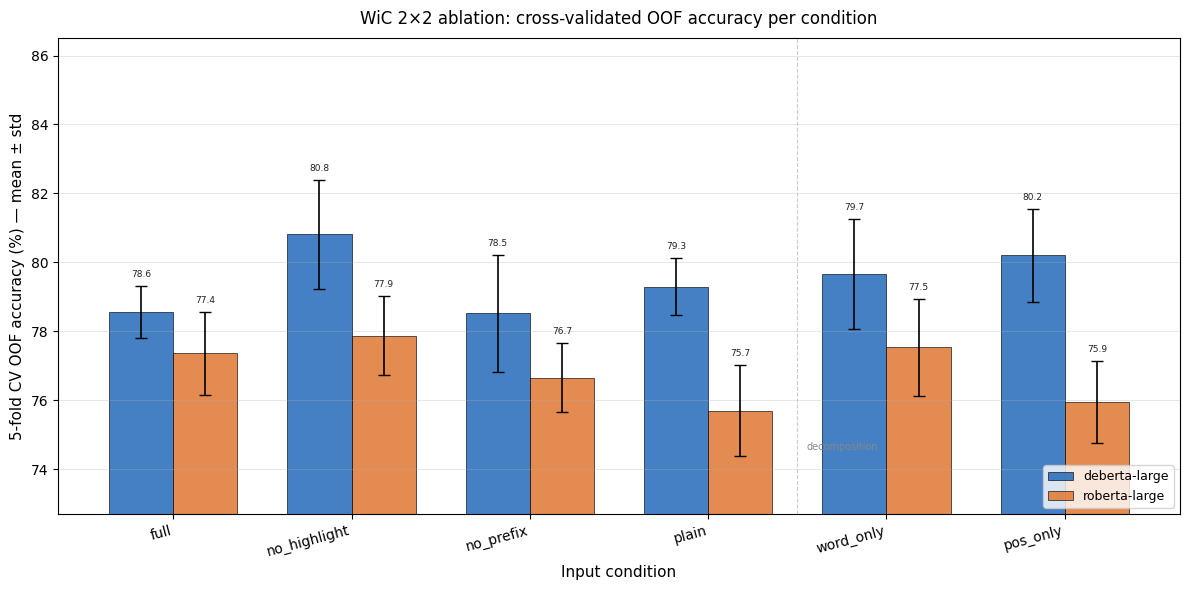

Figura CV salvata in: /content/drive/MyDrive/wic_paper/ablation_plot_cv.png
Caricala su Overleaf e sostituisci ablation_plot.png con ablation_plot_cv.png nel .tex


In [ ]:
# =====================================================================
#  wic_cv_figure.py  —  Genera la figura CV per il paper
#  Prerequisito: cv_ablation_summary.csv su Drive (generato da CV-6).
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# --- Percorsi (adatta se diversi) ---
CV_DIR    = PERSIST_DIR / "cv"           # definito dalla sez. 1 del notebook
PLOT_PATH = PERSIST_DIR / "ablation_plot_cv.png"

df = pd.read_csv(CV_DIR / "cv_ablation_summary.csv")
backbones = df["backbone"].unique().tolist()

# Ordine condizioni: prima le 4 core, poi la decomposizione
COND_ORDER = ["full", "no_highlight", "no_prefix", "plain", "word_only", "pos_only"]
COND_LABELS = {
    "full":         "full",
    "no_highlight": "no_highlight",
    "no_prefix":    "no_prefix",
    "plain":        "plain",
    "word_only":    "word_only",
    "pos_only":     "pos_only",
}

conds = [c for c in COND_ORDER if c in df["condition"].values]
x = np.arange(len(conds))
n_bb = len(backbones)
width = 0.72 / max(n_bb, 1)

# --- Palette colori ---
COLORS = ["#2a6ebb", "#e07b39"]   # blu DeBERTa, arancione RoBERTa

fig, ax = plt.subplots(figsize=(12, 6))

# Linea verticale separatore tra condizioni core e decomposizione
if "word_only" in conds:
    sep = conds.index("word_only") - 0.5
    ax.axvline(x=sep, color="#aaaaaa", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.text(sep + 0.05, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 74.5,
            "decomposition", fontsize=7, color="#888888", va="bottom")

for i, (backbone, color) in enumerate(zip(backbones, COLORS)):
    means, stds = [], []
    for cn in conds:
        row = df[(df["backbone"] == backbone) & (df["condition"] == cn)]
        if len(row) == 0:
            means.append(np.nan); stds.append(0)
        else:
            means.append(float(row["acc_fold_mean"].values[0]) * 100)
            stds.append(float(row["acc_fold_std"].values[0]) * 100)
    offset = (i - (n_bb - 1) / 2) * width
    bars = ax.bar(
        x + offset, means, width,
        yerr=stds, capsize=4,
        label=backbone.split("/")[-1],
        color=color, edgecolor="black", linewidth=0.5, alpha=0.88,
        error_kw={"elinewidth": 1.2, "ecolor": "black"}
    )
    # Etichetta valore sopra ogni barra
    for bar, mean, std in zip(bars, means, stds):
        if not np.isnan(mean):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    mean + std + 0.2,
                    f"{mean:.1f}", ha="center", va="bottom",
                    fontsize=6.5, color="#222222")

# --- Aspetto grafico ---
ax.set_xticks(x)
ax.set_xticklabels([COND_LABELS[c] for c in conds], rotation=15, ha="right", fontsize=10)
ax.set_ylabel("5-fold CV OOF accuracy (%) — mean ± std", fontsize=11)
ax.set_xlabel("Input condition", fontsize=11)
ax.set_title("WiC 2×2 ablation: cross-validated OOF accuracy per condition", fontsize=12, pad=10)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, axis="y", alpha=0.3, linewidth=0.7)

# Non mettere benchmark test (SenseBERT) nella stessa figura: i numeri non sono comparabili.
ymin = max(0, min(m for m in [v for v in [*means] if not np.isnan(v)]) - 3) if any(not np.isnan(m) for m in means) else 70
ax.set_ylim(bottom=ymin)

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()


In [ ]:

print(dev_df['pos'].value_counts())

pos
N    638
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configurazione globale per pubblicazioni scientifiche (font vettoriali nitidi)
plt.rcParams['text.usetex'] = False  # Cambia in True se hai una distribuzione LaTeX installata nel sistema
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# Definizione dei percorsi (ereditati dal tuo setup su Drive)
PERSIST_DIR = Path("/content/drive/MyDrive/wic_paper")
CV_DIR = PERSIST_DIR / "cv"
PLOT_PATH = PERSIST_DIR / "ablation_plot_cv_300dpi.png"

df = pd.read_csv(CV_DIR / "cv_ablation_summary.csv")
backbones = df["backbone"].unique().tolist()

# Configurazione dell'ordine e dei nomi delle etichette (core + decomposition)
COND_ORDER = ["full", "no_highlight", "no_prefix", "plain", "word_only", "pos_only"]
COND_LABELS = {c: c for c in COND_ORDER}
conds = [c for c in COND_ORDER if c in df["condition"].values]

# 2. Impostazione delle geometrie del grafico
x = np.arange(len(conds))
n_bb = len(backbones)
width = 0.72 / max(n_bb, 1)
COLORS = ["#2a6ebb", "#e07b39"]  # Blu DeBERTa, Arancione RoBERTa

# Creazione della figura impostando esplicitamente i DPI di visualizzazione
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

# Linea verticale di separazione per l'analisi di decomposizione
if "word_only" in conds:
    sep = conds.index("word_only") - 0.5
    ax.axvline(x=sep, color="#aaaaaa", linewidth=1.0, linestyle="--", alpha=0.7)
    ax.text(sep + 0.05, 74.5, "decomposition", fontsize=8, color="#777777", va="bottom", fontstyle="italic")

# 3. Disegno delle barre con relativi intervalli di errore (std)
for i, (backbone, color) in enumerate(zip(backbones, COLORS)):
    means, stds = [], []
    for cn in conds:
        row = df[(df["backbone"] == backbone) & (df["condition"] == cn)]
        if len(row) == 0:
            means.append(np.nan)
            stds.append(0)
        else:
            means.append(float(row["acc_fold_mean"].values[0]) * 100)
            stds.append(float(row["acc_fold_std"].values[0]) * 100)

    offset = (i - (n_bb - 1) / 2) * width
    bars = ax.bar(
        x + offset, means, width,
        yerr=stds, capsize=5,
        label=backbone.split("/")[-1],
        color=color, edgecolor="black", linewidth=0.6, alpha=0.9,
        error_kw={"elinewidth": 1.2, "ecolor": "black"}
    )

    # Visualizzazione dinamica del valore sopra ogni barra (artondato a 1 decimale)
    for bar, mean, std in zip(bars, means, stds):
        if not np.isnan(mean):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                mean + std + 0.15,
                f"{mean:.1f}", ha="center", va="bottom",
                fontsize=7.5, color="#111111", weight="bold"
            )

# 4. Rifinitura estetica del layout
ax.set_xticks(x)
ax.set_xticklabels([COND_LABELS[c] for c in conds], rotation=15, ha="right", fontsize=10)
ax.set_ylabel("5-fold CV OOF Accuracy (%) mean $\pm$ std", fontsize=11, labelpad=8)
ax.set_xlabel("Input Condition", fontsize=11, labelpad=8)
ax.set_title("WiC 2$\\times$2 Ablation: Cross-Validated OOF Accuracy Per Condition", fontsize=12, pad=12, weight="bold")
ax.legend(fontsize=9.5, loc="lower right", frameon=True, facecolor="white", edgecolor="none")
ax.grid(True, axis="y", alpha=0.3, linewidth=0.7, linestyle=":")

# Impostazione dinamica dell'asse Y per ottimizzare lo spazio visivo superiore
if any(not np.isnan(m) for m in means):
    ymin = max(0, min([v for v in df["acc_fold_mean"].values * 100 if not np.isnan(v)]) - 3)
    ax.set_ylim(bottom=ymin, top=86)

# 5. ESPORTAZIONE AD ALTA RISOLUZIONE (Il nucleo dell'ottimizzazione)
# `bbox_inches="tight"` assicura che scritte ruotate o etichette degli assi non vengano tagliate fuori dal foglio.
plt.savefig(PLOT_PATH, dpi=300, bbox_inches="tight", format="png")
plt.close()

print(f"Grafico ad alta risoluzione (300 DPI) salvato correttamente in:\n{PLOT_PATH}")

Grafico ad alta risoluzione (300 DPI) salvato correttamente in:
/content/drive/MyDrive/wic_paper/ablation_plot_cv_300dpi.png


In [ ]:
# %% === CV-9. Error analysis: esempi recuperati/perduti dai marker ===
# Confronto principale: DeBERTa-large full vs no_highlight
# recovered = full sbaglia, no_highlight corregge
# lost      = full corregge, no_highlight sbaglia

import json
import numpy as np
import pandas as pd
from pathlib import Path

CV_OOF_PATH = PERSIST_DIR / "cv" / "cv_oof_preds.json"

with open(CV_OOF_PATH) as f:
    oof = json.load(f)

# Ricostruisce predizioni OOF complete per backbone/condition
def assemble_oof(backbone, condition, n_pool):
    pred = np.full(n_pool, -1, dtype=int)
    for fold in range(K_FOLDS):
        key = f"{backbone}||{condition}||fold{fold}"
        if key not in oof:
            raise KeyError(f"Manca {key} in cv_oof_preds.json")
        d = oof[key]
        idx = np.array(d["idx"], dtype=int)
        pr = np.array(d["pred"], dtype=int)
        pred[idx] = pr
    if np.any(pred < 0):
        missing = np.where(pred < 0)[0][:10]
        raise ValueError(f"Predizioni mancanti, esempi: {missing}")
    return pred

backbone = "microsoft/deberta-large"
pred_full = assemble_oof(backbone, "full", N_POOL)
pred_nohl = assemble_oof(backbone, "no_highlight", N_POOL)

gold = GOLD.astype(int)

full_correct = pred_full == gold
nohl_correct = pred_nohl == gold

recovered_idx = np.where((~full_correct) & (nohl_correct))[0]
lost_idx = np.where((full_correct) & (~nohl_correct))[0]
both_correct_idx = np.where((full_correct) & (nohl_correct))[0]
both_wrong_idx = np.where((~full_correct) & (~nohl_correct))[0]

print("DeBERTa-large: full vs no_highlight")
print(f"Recovered by removing markers: {len(recovered_idx)}")
print(f"Lost after removing markers:      {len(lost_idx)}")
print(f"Net gain:                         {len(recovered_idx) - len(lost_idx)}")
print(f"Both correct:                      {len(both_correct_idx)}")
print(f"Both wrong:                        {len(both_wrong_idx)}")
print(f"Total:                             {N_POOL}")

# Feature semplici per descrivere i casi
def target_position_bin(row, n):
    start = int(row[f"start{n}"])
    sent_len = max(len(row[f"sentence{n}"]), 1)
    ratio = start / sent_len
    if ratio < 0.33:
        return "early"
    elif ratio < 0.66:
        return "middle"
    else:
        return "late"

def target_repeated(row, n):
    word = str(row["word"]).lower()
    sent = str(row[f"sentence{n}"]).lower()
    return sent.count(word) > 1

def build_error_df(indices, label):
    rows = []
    for i in indices:
        r = pool_df.iloc[i]
        rows.append({
            "case_type": label,
            "idx_pool": int(i),
            "word": r["word"],
            "gold": int(gold[i]),
            "pred_full": int(pred_full[i]),
            "pred_no_highlight": int(pred_nohl[i]),
            "pos1_bin": target_position_bin(r, 1),
            "pos2_bin": target_position_bin(r, 2),
            "repeated_s1": target_repeated(r, 1),
            "repeated_s2": target_repeated(r, 2),
            "sentence1": r["sentence1"],
            "sentence2": r["sentence2"],
        })
    return pd.DataFrame(rows)

recovered_df = build_error_df(recovered_idx, "recovered_by_no_highlight")
lost_df = build_error_df(lost_idx, "lost_by_no_highlight")

error_df = pd.concat([recovered_df, lost_df], ignore_index=True)

out_csv = PERSIST_DIR / "cv" / "marker_error_analysis_full_vs_no_highlight.csv"
error_df.to_csv(out_csv, index=False)
print("Salvato:", out_csv)

# Sintesi quantitativa semplice
summary = pd.concat([
    recovered_df.assign(group="recovered"),
    lost_df.assign(group="lost")
])

print("\nDistribuzione posizione target s1:")
print(pd.crosstab(summary["group"], summary["pos1_bin"], normalize="index").round(3))

print("\nDistribuzione posizione target s2:")
print(pd.crosstab(summary["group"], summary["pos2_bin"], normalize="index").round(3))

print("\nTarget ripetuto nella frase:")
print(pd.DataFrame({
    "recovered_repeated_s1": [recovered_df["repeated_s1"].mean()],
    "lost_repeated_s1": [lost_df["repeated_s1"].mean()],
    "recovered_repeated_s2": [recovered_df["repeated_s2"].mean()],
    "lost_repeated_s2": [lost_df["repeated_s2"].mean()],
}).round(3))

# Esempi qualitativi brevi da ispezionare manualmente
display_cols = [
    "case_type", "word", "gold", "pred_full", "pred_no_highlight",
    "sentence1", "sentence2"
]

print("\nEsempi recuperati:")
display(recovered_df[display_cols].head(8))

print("\nEsempi perduti:")
display(lost_df[display_cols].head(8))

DeBERTa-large: full vs no_highlight
Recovered by removing markers: 504
Lost after removing markers:      367
Net gain:                         137
Both correct:                      4398
Both wrong:                        797
Total:                             6066
Salvato: /content/drive/MyDrive/wic_paper/cv/marker_error_analysis_full_vs_no_highlight.csv

Distribuzione posizione target s1:
pos1_bin   early   late  middle
group                          
lost       0.501  0.223   0.275
recovered  0.560  0.171   0.270

Distribuzione posizione target s2:
pos2_bin   early   late  middle
group                          
lost       0.496  0.191   0.313
recovered  0.486  0.181   0.333

Target ripetuto nella frase:
   recovered_repeated_s1  lost_repeated_s1  recovered_repeated_s2  \
0                  0.008             0.008                  0.004   

   lost_repeated_s2  
0               0.0  

Esempi recuperati:


,case_type,word,gold,pred_full,pred_no_highlight,sentence1,sentence2
0,recovered_by_no_highlight,land,1,0,1,It can be tricky to land a helicopter.,Use the net to land the fish.
1,recovered_by_no_highlight,roll,0,1,0,Roll out the paper.,The drawer rolled open.
2,recovered_by_no_highlight,connection,1,0,1,The connection between church and state is ine...,My headache has no connection with me going ou...
3,recovered_by_no_highlight,boy,1,0,1,Steve is a boy of 16.,She made the boy brush his teeth every night.
4,recovered_by_no_highlight,take,0,1,0,Take a scene.,Take a test.
5,recovered_by_no_highlight,title,0,1,0,"A good title to an estate, or an imperfect title.",His title to fame.
6,recovered_by_no_highlight,make,0,1,0,To make like a deer caught in the headlights.,He will make a splendid father!
7,recovered_by_no_highlight,approach,1,0,1,Don't approach that house.,"He was an admirable poet, and thought even to ..."



Esempi perduti:


,case_type,word,gold,pred_full,pred_no_highlight,sentence1,sentence2
0,lost_by_no_highlight,subvert,0,0,1,Do school counselors subvert young children?,We must not let our civil liberties be subvert...
1,lost_by_no_highlight,pull,0,0,1,Pull the oars.,Pull the trigger of the gun.
2,lost_by_no_highlight,land,1,1,0,It can be tricky to land a helicopter.,This may land you in jail.
3,lost_by_no_highlight,snap,0,0,1,He gave his fingers a snap.,Servants appeared at the snap of his fingers.
4,lost_by_no_highlight,work,0,0,1,Can you work an electric drill?,Work the metal into a sword.
5,lost_by_no_highlight,setup,0,0,1,It takes time to learn the setup around here.,The laboratory included an elaborate setup for...
6,lost_by_no_highlight,pack,0,0,1,You had better pack your swollen ankle with ice.,Pack the books into the boxes.
7,lost_by_no_highlight,plug,1,1,0,Plug the hole.,He attempted to plug the leaks with some caulk.


<>:64: SyntaxWarning: invalid escape sequence '\D'
<>:64: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_16535/3937630396.py:64: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('Accuracy Delta ($\Delta$ pp)')


Mounted at /content/drive
Grafico salvato con successo in: /content/drive/MyDrive/factorial_contrasts.pdf


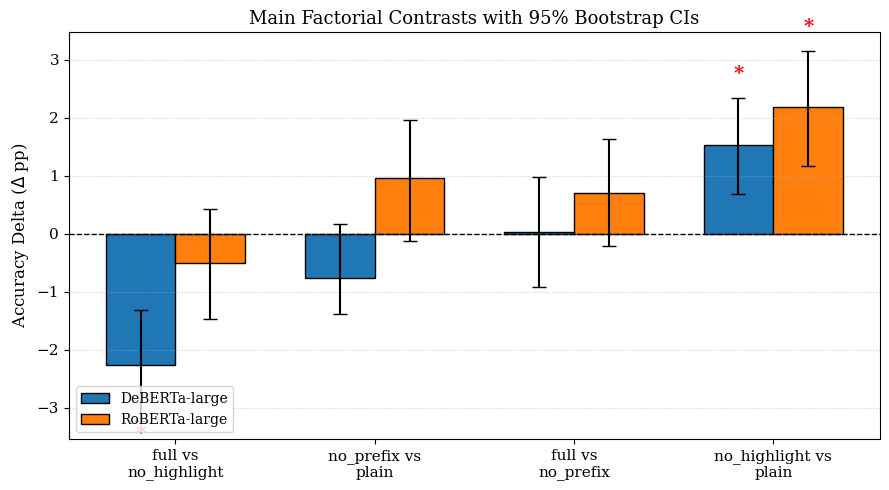

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- AGGIUNTA PER GOOGLE DRIVE ---
# Importa la libreria per montare il Drive (valido in Google Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # Puoi cambiare 'factorial_contrasts.pdf' con il percorso di una cartella specifica, es: '/content/drive/MyDrive/CartellaPaper/factorial_contrasts.pdf'
    save_path = '/content/drive/MyDrive/factorial_contrasts.pdf'
except ImportError:
    # Se non sei su Colab, salva nella cartella locale corrente
    print("Non sei in un ambiente Google Colab. Il file verrà salvato localmente.")
    save_path = 'factorial_contrasts.pdf'
# ----------------------------------

# Configurazione stile scientifico
plt.rcParams['font.family'] = 'serif'
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13

# Dati estratti dalla Tabella 5 del paper
contrasts = [
    'full vs\nno_highlight',
    'no_prefix vs\nplain',
    'full vs\nno_prefix',
    'no_highlight vs\nplain'
]

# Delta accuratezza (punti percentuali)
deberta_deltas = [-2.26, -0.77, 0.03, 1.52]
roberta_deltas = [-0.51, 0.96, 0.71, 2.18]

# Errori basati sugli intervalli di confidenza al 95% (calcolo della semi-ampiezza)
deberta_err = [
    [2.26 - 1.30, 0.77 - 0.16, 0.03 - (-0.91), 1.52 - 0.68],
    [3.20 - 2.26, 1.71 - 0.77, 0.97 - 0.03, 2.34 - 1.52]
]

roberta_err = [
    [0.51 - (-0.45), 0.96 - (-0.12), 0.71 - (-0.21), 2.18 - 1.17],
    [1.45 - 0.51, 1.96 - 0.96, 1.63 - 0.71, 3.15 - 2.18]
]

x = np.arange(len(contrasts))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

# Barre per DeBERTa-large
rects1 = ax.bar(x - width/2, deberta_deltas, width, yerr=deberta_err,
                label='DeBERTa-large', color='#1f77b4', edgecolor='black', capsize=5)
# Barre per RoBERTa-large
rects2 = ax.bar(x + width/2, roberta_deltas, width, yerr=roberta_err,
                label='RoBERTa-large', color='#ff7f0e', edgecolor='black', capsize=5)

# Linea di riferimento sullo zero (nessun effetto)
ax.axhline(0, color='black', linestyle='--', linewidth=1)

# Annotazioni e dettagli estetici
ax.set_ylabel('Accuracy Delta ($\Delta$ pp)')
ax.set_title('Main Factorial Contrasts with 95% Bootstrap CIs')
ax.set_xticks(x)
ax.set_xticklabels(contrasts)
ax.legend(frameon=True, loc='lower left')
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Aggiunta di asterischi per i contrasti significativi (p_Holm < 0.05)
ax.text(0 - width/2, -3.6, '*', ha='center', va='bottom', fontsize=14, weight='bold', color='red')
ax.text(3 - width/2, 2.6, '*', ha='center', va='bottom', fontsize=14, weight='bold', color='red')
ax.text(3 + width/2, 3.4, '*', ha='center', va='bottom', fontsize=14, weight='bold', color='red')

plt.tight_layout()

# --- MODIFICATO PER SALVARE SU DRIVE ---
# Salva il grafico utilizzando il percorso configurato (Drive o Locale)
plt.savefig(save_path, bbox_inches='tight')
print(f"Grafico salvato con successo in: {save_path}")

plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Grafico salvato correttamente in: /content/drive/MyDrive/factorial_contrasts.pdf


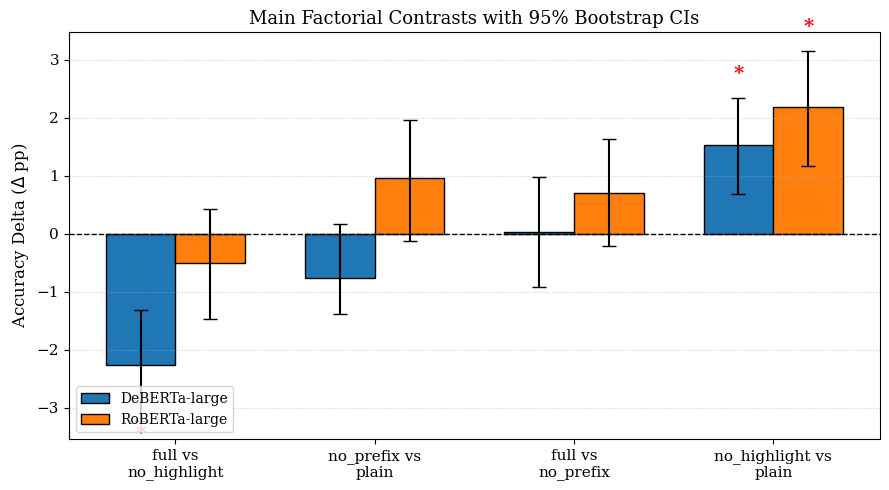

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- AGGIUNTA PER GOOGLE DRIVE ---
try:
    from google.colab import drive
    drive.mount('/content/drive')

    # Cartella di destinazione su Drive
    # Puoi anche definire una sottocartella, es: '/content/drive/MyDrive/GraficiPaper'
    output_dir = '/content/drive/MyDrive'
    save_path = os.path.join(output_dir, 'factorial_contrasts.pdf')

    # Crea la cartella se non esiste (evita errori di "Directory not found")
    os.makedirs(output_dir, exist_ok=True)

except ImportError:
    print("Non sei in un ambiente Google Colab. Il file verrà salvato localmente.")
    save_path = 'factorial_contrasts.pdf'
# ----------------------------------

# Configurazione stile scientifico
plt.rcParams['font.family'] = 'serif'
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13

# Dati estratti dalla Tabella 5 del paper
contrasts = [
    'full vs\nno_highlight',
    'no_prefix vs\nplain',
    'full vs\nno_prefix',
    'no_highlight vs\nplain'
]

# Delta accuratezza (punti percentuali)
deberta_deltas = [-2.26, -0.77, 0.03, 1.52]
roberta_deltas = [-0.51, 0.96, 0.71, 2.18]

# Errori basati sugli intervalli di confidenza al 95% (calcolo della semi-ampiezza)
deberta_err = [
    [2.26 - 1.30, 0.77 - 0.16, 0.03 - (-0.91), 1.52 - 0.68],
    [3.20 - 2.26, 1.71 - 0.77, 0.97 - 0.03, 2.34 - 1.52]
]

roberta_err = [
    [0.51 - (-0.45), 0.96 - (-0.12), 0.71 - (-0.21), 2.18 - 1.17],
    [1.45 - 0.51, 1.96 - 0.96, 1.63 - 0.71, 3.15 - 2.18]
]

x = np.arange(len(contrasts))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

# Barre per DeBERTa-large
rects1 = ax.bar(x - width/2, deberta_deltas, width, yerr=deberta_err,
                label='DeBERTa-large', color='#1f77b4', edgecolor='black', capsize=5)
# Barre per RoBERTa-large
rects2 = ax.bar(x + width/2, roberta_deltas, width, yerr=roberta_err,
                label='RoBERTa-large', color='#ff7f0e', edgecolor='black', capsize=5)

# Linea di riferimento sullo zero (nessun effetto)
ax.axhline(0, color='black', linestyle='--', linewidth=1)

# Annotazioni e dettagli estetici
ax.set_ylabel('Accuracy Delta ($\Delta$ pp)')
ax.set_title('Main Factorial Contrasts with 95% Bootstrap CIs')
ax.set_xticks(x)
ax.set_xticklabels(contrasts)
ax.legend(frameon=True, loc='lower left')
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Aggiunta di asterischi per i contrasti significativi (p_Holm < 0.05)
ax.text(0 - width/2, -3.6, '*', ha='center', va='bottom', fontsize=14, weight='bold', color='red')
ax.text(3 - width/2, 2.6, '*', ha='center', va='bottom', fontsize=14, weight='bold', color='red')
ax.text(3 + width/2, 3.4, '*', ha='center', va='bottom', fontsize=14, weight='bold', color='red')

plt.tight_layout()

# --- CORREZIONE: Salva PRIMA di mostrare a schermo ---
plt.savefig(save_path, bbox_inches='tight')
print(f"Grafico salvato correttamente in: {save_path}")

# Mostra il grafico nell'output di Colab
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Grafico salvato con successo in: /content/drive/MyDrive/factorial_contrasts.pdf


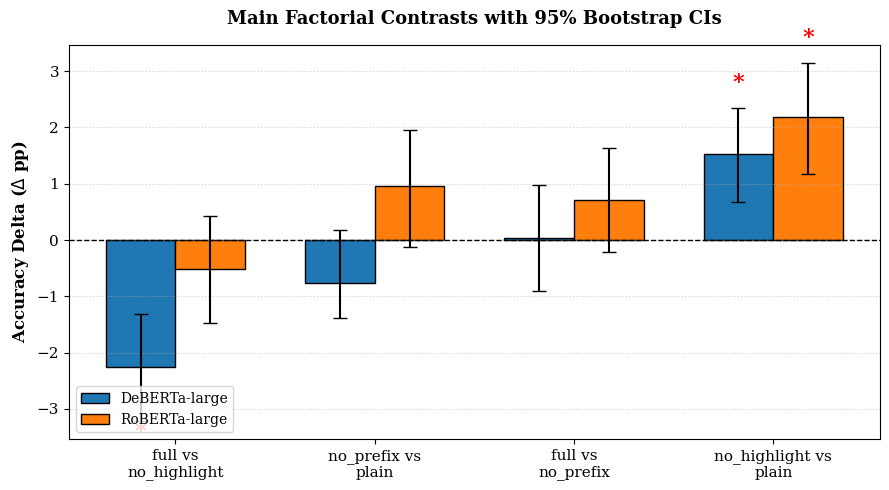

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- AGGIUNTA PER GOOGLE DRIVE ---
try:
    from google.colab import drive
    drive.mount('/content/drive')

    output_dir = '/content/drive/MyDrive'
    save_path = os.path.join(output_dir, 'factorial_contrasts.pdf')

    # Assicura che la directory esista
    os.makedirs(output_dir, exist_ok=True)
except ImportError:
    print("Non sei in un ambiente Google Colab. Il file verrà salvato localmente.")
    save_path = 'factorial_contrasts.pdf'
# ----------------------------------

# Configurazione grafica per paper scientifici (font serif coordinato a LaTeX)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13

# 1. Definizione dei Contrasti Fattoriali (Dati estratti dalla Tabella 5 del Paper)
contrasts = [
    'full vs\nno_highlight',
    'no_prefix vs\nplain',
    'full vs\nno_prefix',
    'no_highlight vs\nplain'
]

# Delta delle accuratezze in punti percentuali (pp)
deberta_deltas = [-2.26, -0.77, 0.03, 1.52]
roberta_deltas = [-0.51, 0.96, 0.71, 2.18]

# 2. Calcolo delle semiampiezze degli Intervalli di Confidenza al 95% (Bootstrap)
deberta_err = [
    [2.26 - 1.30, 0.77 - 0.16, 0.03 - (-0.91), 1.52 - 0.68],  # Distanza dal limite inferiore
    [3.20 - 2.26, 1.71 - 0.77, 0.97 - 0.03, 2.34 - 1.52]      # Distanza dal limite superiore
]

roberta_err = [
    [0.51 - (-0.45), 0.96 - (-0.12), 0.71 - (-0.21), 2.18 - 1.17],
    [1.45 - 0.51, 1.96 - 0.96, 1.63 - 0.71, 3.15 - 2.18]
]

x = np.arange(len(contrasts))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

# Plot delle barre con relative barre d'errore
rects1 = ax.bar(x - width/2, deberta_deltas, width, yerr=deberta_err,
                label='DeBERTa-large', color='#1f77b4', edgecolor='black', capsize=5)
rects2 = ax.bar(x + width/2, roberta_deltas, width, yerr=roberta_err,
                label='RoBERTa-large', color='#ff7f0e', edgecolor='black', capsize=5)

# Linea di riferimento orizzontale sullo ZERO
ax.axhline(0, color='black', linestyle='--', linewidth=1)

# Etichette e stilizzazione
ax.set_ylabel('Accuracy Delta ($\Delta$ pp)', weight='bold')
ax.set_title('Main Factorial Contrasts with 95% Bootstrap CIs', weight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(contrasts)
ax.legend(frameon=True, loc='lower left', fontsize=10)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# 3. Annotazione degli asterischi (*) per i soli contrasti significativi (p_Holm < 0.05)
# DeBERTa-large: significativi 'full vs no_highlight' e 'no_highlight vs plain'
ax.text(0 - width/2, -3.6, '*', ha='center', va='bottom', fontsize=16, weight='bold', color='red')
ax.text(3 - width/2, 2.6, '*', ha='center', va='bottom', fontsize=16, weight='bold', color='red')

# RoBERTa-large: significativo solo 'no_highlight vs plain'
ax.text(3 + width/2, 3.4, '*', ha='center', va='bottom', fontsize=16, weight='bold', color='red')

plt.tight_layout()

plt.savefig(save_path, bbox_inches='tight')
print(f"Grafico salvato con successo in: {save_path}")

# Mostra il grafico a schermo in Colab
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Grafico salvato con successo in: /content/drive/MyDrive/prefix_decomposition.pdf


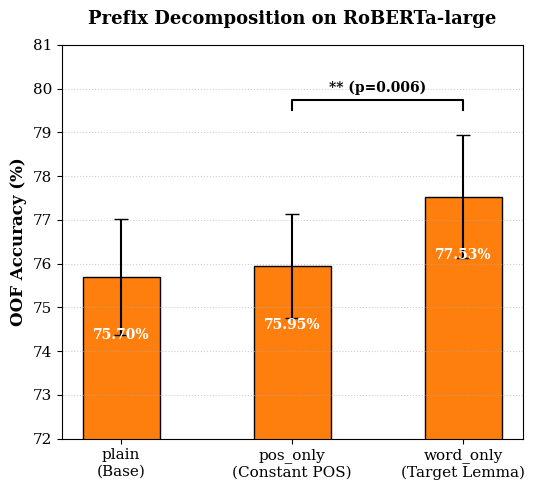

In [ ]:
import matplotlib.pyplot as plt
import os

# --- AGGIUNTA PER GOOGLE DRIVE ---
try:
    from google.colab import drive
    drive.mount('/content/drive')

    output_dir = '/content/drive/MyDrive'
    save_path = os.path.join(output_dir, 'prefix_decomposition.pdf')

    # Assicura che la directory esista
    os.makedirs(output_dir, exist_ok=True)
except ImportError:
    print("Non sei in un ambiente Google Colab. Il file verrà salvato localmente.")
    save_path = 'prefix_decomposition.pdf'
# ----------------------------------

# Accuratezze assolute estratte dalla Tabella 4 per RoBERTa-large
conditions = ['plain\n(Base)', 'pos_only\n(Constant POS)', 'word_only\n(Target Lemma)']
accuracies = [75.70, 75.95, 77.53]
errors = [1.32, 1.19, 1.40] # Deviazioni standard calcolate sui 5 fold

fig, ax = plt.subplots(figsize=(5.5, 5))

# Generazione del barplot
bars = ax.bar(conditions, accuracies, color='#ff7f0e', edgecolor='black', width=0.45, yerr=errors, capsize=5)

# Ottimizzazione del range dell'asse Y per evidenziare la variazione senza distorcere la percezione grafica
ax.set_ylim(72, 81)
ax.set_ylabel('OOF Accuracy (%)', weight='bold')
ax.set_title('Prefix Decomposition on RoBERTa-large', weight='bold', pad=15)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Disegno manuale della staffa di significatività statistica (Contrasto word_only vs pos_only, p = 0.006)
x1, x2 = 1, 2
y, h, col = 79.5, 0.25, 'black'
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
ax.text((x1+x2)*.5, y+h+0.1, "** (p=0.006)", ha='center', va='bottom', color='black', weight='bold', fontsize=10)

# Inserimento dei valori percentuali all'interno delle colonne per una lettura immediata
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height - 1.5, f'{height:.2f}%',
            ha='center', va='bottom', color='white', weight='bold', fontsize=10)

plt.tight_layout()

plt.savefig(save_path, bbox_inches='tight')
print(f"Grafico salvato con successo in: {save_path}")

# Mostra il grafico nell'output
plt.show()